# Ball on incline experiment

href to the webpage here

## Import packages and data 

In [148]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit import cost
from scipy import stats

In [149]:
#import csv files
data1 = np.loadtxt( 'incline_data/50 kHz/normal_small_1.csv', delimiter=',', skiprows=15)
data2 = np.loadtxt('incline_data/50 kHz/reverse_small_1.csv', delimiter=',', skiprows=15)


In [150]:
# plotting the data to see if the raw data is loaded and has been taken correctly
# do a mask from t = 0.25s to t = 1.0s

# mask = (data1[:,0] >= 0.3) & (data1[:,0] <= 1.)
# data1 = data1[mask]

def plot_raw_data(name):
    data = np.loadtxt(name, delimiter=',', skiprows=15)
    plt.ylim(0.,6)
    plt.plot(data[:,0], data[:,1], '.')
    plt.title(name)
    plt.xlabel('Time [s]')
    plt.ylabel('Voltage [V]')
    plt.show()
    return True

# for i in all_ball_files:
    # plot_raw_data(i)


In [151]:
# lengths and angles measured by hand

locs1 = np.array([[82.15,67.15,51.95,37.05,21.45]
                 ,[82.17,67.19,51.91,37.05,21.41]
                 ,[82.08,67.16,51.91,37.01,21.43]
                 ,[82.15,67.2 ,51.65,37.  ,21.45]
                 ,[82.15,67.15,51.9 ,37.05,21.4 ]])/100     # lengths in m
locs_errors = np.array([0.15,0.1,0.15,0.2,0.1])/100         # estimated uncertainties in m
loc_error   = np.sqrt(1.0/np.sum(1.0/np.square(locs_errors)))
locs = np.average(locs1, axis=0, weights=1/locs_errors**2)

gonio_a_norm = np.ones(5)*75.9
gonio_b_norm = np.ones(5)*76.2
gonio_a_reverse = np.ones(5)*76.2
gonio_b_reverse = np.ones(5)*75.9

gonio_err = np.ones(5)*0.1
gonio_err_accum = 0.1/np.sqrt(5)

gonio_norm = (gonio_a_norm[0] + gonio_b_norm[0])/2
gonio_reverse = (gonio_a_reverse[0] + gonio_b_reverse[0])/2
gonio_avg_err = np.sqrt(2)*gonio_err_accum
d_theta_gonio_err = 2*gonio_err_accum
gonio_avg = (gonio_norm + gonio_reverse)/2
d_theta_gonio = (gonio_norm - gonio_reverse)/2
print(f'gonio_avg     = {90-(gonio_norm+ gonio_reverse)/2 :.2f}± {gonio_avg_err:.2f}')
print(f'd_theta_gonio = {d_theta_gonio} ± {d_theta_gonio_err:.2f}')

DistH = 0.8879
DistH_err = 0.0005
height = 0.221
height_err = 0.001




# angle and error propagation (theta = arctan(height / DistH))
r = height / DistH
theta_rad = np.arctan(r)

# derivatives for propagation
dr_dh = 1.0 / DistH
dr_dD = -height / DistH**2

# propagate to r then to theta (dθ/dr = 1/(1+r^2))
sigma_r = np.sqrt((dr_dh * height_err)**2 + (dr_dD * DistH_err)**2)
sigma_theta = sigma_r / (1.0 + r**2)

# convert to degrees
theta_deg = np.degrees(theta_rad)
sigma_theta_deg = np.degrees(sigma_theta)

print(f"theta = {theta_rad:.6f} rad ± {sigma_theta:.6f} rad  ({theta_deg:.3f}° ± {sigma_theta_deg:.3f}°)")

theta_avg = (90 + theta_deg - gonio_avg)/2

d_r = 6./1000
d_r_err = 0.1/(1000*np.sqrt(5))
print(f'{d_r_err:.6f}')

db_s = np.array([10,9.9,9.9,10,9.8])/1000
db_s_err = 0.0001/np.sqrt(5)
db_s_err = np.sqrt(db_s_err**2 + np.var(db_s))
db_s=np.mean(db_s)
db_m = 0.0112
db_m_err = 0.0001/np.sqrt(5)
db_b = 0.0149
db_b_err = 0.0001/np.sqrt(5)

gonio_avg     = 13.95± 0.06
d_theta_gonio = 0.0 ± 0.09
theta = 0.243945 rad ± 0.001069 rad  (13.977° ± 0.061°)
0.000045


## Define nescesary functions

In [152]:
# Find times at which theball activates the sensors and find the first location above a specified value for each sensor activation.

def find_sensor_times(data, threshold=0.0, threshold_error = 1.0):
    sensor_times = []
    sensor_times_error = []
    sensor_locs = []
    sensor_locs_error = []
    above_threshold = data[:,1] > threshold
    above_threshold_error = data[:,1] > threshold_error
    for i in range(1, len(above_threshold)):
        if above_threshold[i] and not above_threshold[i-1]:
            sensor_times.append(data[i,:])
            sensor_locs.append(i)
        if above_threshold_error[i] and not above_threshold_error[i-1]:
            sensor_times_error.append(data[i,:])
            sensor_locs_error.append(i)

    for i in range(len(sensor_times_error)):
        sensor_times_error[i] -= sensor_times[i]

    return np.array(sensor_times), np.array(sensor_times_error), np.array(sensor_locs), np.array(sensor_locs_error)


In [153]:
def model(t, a, v0, x0):
    return a * t**2/2 + v0 * t + x0

In [154]:
def accelration_from_data(data_name, locs, loc_error, threhold=1.0):
    data = np.loadtxt( data_name, delimiter=',', skiprows=15)
    sensor_times, sensor_times_error, sensor_locs, sensor_locs_error = find_sensor_times(data, threshold=threhold, threshold_error=2.)
    times = sensor_times[:,0]
    ls = cost.LeastSquares(times, locs, np.ones_like(locs)*loc_error, model)
    m = Minuit(ls, a=1, v0=0.01, x0=0)
    m.migrad()
    return m.values['a'], m.errors['a'], m.fval, stats.chi2.sf(m.fval, 3)

def multiple_accellerations(names, locs, loc_error, threshold=1.0):
    accs = []
    acc_errors = []
    chisq = []
    p_values = []
    for name in names:
        a, a_err, chi2, p = accelration_from_data(name, locs, loc_error, threhold=threshold)
        accs.append(a)
        acc_errors.append(a_err)
        chisq.append(chi2)
        p_values.append(p)
    return np.array(accs), np.array(acc_errors), np.array(chisq), np.array(p_values)


## Plots

In [155]:
sensor_times1, sensor_times_error1, sensor_locs1, sensor_locs_error1 = find_sensor_times(data1, threshold=1.0, threshold_error=2.)
sensor_times2, sensor_times_error2, sensor_locs2, sensor_locs_error2 = find_sensor_times(data2, threshold=1.0, threshold_error=2.)

# locs_error = np.ones_like(locs)/np.sqrt( 1/0.15**2 + 1/0.1**2 + 1/0.15**2 + 1/0.2**2 + 1/0.1**2)  # distance uncertainty in centi meters
# print(locs)

times1 = sensor_times1[:,0]
times2 = sensor_times2[:,0]

# plt.plot(times1, locs, 'o')
# plt.title('Ball on incline 1st direction')
# plt.ylabel('Distance [m]')
# plt.xlabel('Time [s]')
# plt.show()



In [156]:
ls = cost.LeastSquares(times1, locs, np.ones_like(locs)*loc_error, model)
m = Minuit(ls, a=1, v0=0.01, x0=0)
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.41 (χ²/ndof = 2.2)       │              Nfcn = 67               │
│ EDM = 1.05e-15 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │  -1.372   │   0.010   │            │            │         │         │       │
│ 1 │ v0   │  -0.5528  │  0.0028   │            │            │         │         │       │
│ 2 │ x0   │ 779.4e-3  │  0.4e-3   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬────────────────────────────┐
│    │        a       v0       x0 │
├────┼────────────────────────────┤
│  a │  0.00011   -27e-6  0.20e-6 │
│ v0 │   -27e-6 7.95e-06 -0.38e-6 │
│ x0 │  0.20e-6 -0.38e-6 1.62e-07 │
└────┴────────────────────────────┘

In [157]:
name = 'a'
print(f'The accelration is: {m.values[name]:.1f} ± { m.errors[name]:.1f} cm/s^2')

The accelration is: -1.4 ± 0.0 cm/s^2


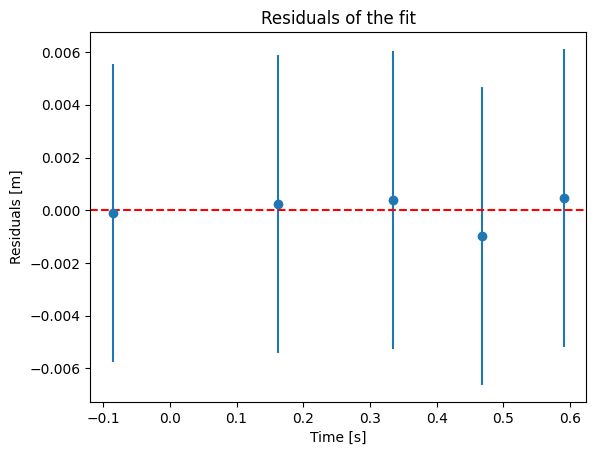

In [158]:
# residual plot
residuals = locs - model(times1, m.values['a'], m.values['v0'], m.values['x0'])
plt.errorbar(times1, residuals, yerr=np.ones_like(locs)*loc_error*10, fmt='o')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals of the fit')
plt.ylabel('Residuals [m]')
plt.xlabel('Time [s]')
plt.show()

## Compiled data

In [159]:
# Small Ball Normal direction
sbn = ['incline_data/50 kHz/normal_small_1.csv', 
       'incline_data/50 kHz/normal_small_2.csv', 
       'incline_data/50 kHz/normal_small_3.csv', 
       'incline_data/50 kHz/normal_small_4.csv', 
       'incline_data/50 kHz/normal_small_5.csv']

# Small Ball Reverse direction
sbr = ['incline_data/50 kHz/reverse_small_1.csv', 
       'incline_data/50 kHz/reverse_small_2.csv', 
       'incline_data/50 kHz/reverse_small_3.csv', 
       'incline_data/50 kHz/reverse_small_4.csv', 
       'incline_data/50 kHz/reverse_small_5.csv']
# Small Ball Normal direction
mbn = ['incline_data/50 kHz/normal_medium_1.csv', 
       'incline_data/50 kHz/normal_medium_2.csv', 
       'incline_data/50 kHz/normal_medium_3.csv', 
       'incline_data/50 kHz/normal_medium_4.csv', 
       'incline_data/50 kHz/normal_medium_5.csv']

# Small Ball Reverse direction
mbr = ['incline_data/50 kHz/reverse_medium_1.csv', 
       'incline_data/50 kHz/reverse_medium_2.csv', 
       'incline_data/50 kHz/reverse_medium_3.csv', 
       'incline_data/50 kHz/reverse_medium_4.csv', 
       'incline_data/50 kHz/reverse_medium_5.csv']

# Small Ball Normal direction
bbn = ['incline_data/50 kHz/normal_big_1.csv', 
       'incline_data/50 kHz/normal_big_2.csv', 
       'incline_data/50 kHz/normal_big_3.csv', 
       'incline_data/50 kHz/normal_big_4.csv', 
       'incline_data/50 kHz/normal_big_5.csv']

# Small Ball Reverse direction
bbr = ['incline_data/50 kHz/reverse_big_1.csv', 
       'incline_data/50 kHz/reverse_big_2.csv', 
       'incline_data/50 kHz/reverse_big_3.csv', 
       'incline_data/50 kHz/reverse_big_4.csv', 
       'incline_data/50 kHz/reverse_big_5.csv']
all_ball_files = sbn + sbr + mbn + mbr + bbn + bbr

In [160]:
print(loc_error)
acc_s, acc_s_err, chi2_vals_s, P_vals_s  = multiple_accellerations(sbn + sbr, locs, loc_error, threshold=1.0)
acc_m, acc_m_err, chi2_vals_m, P_vals_m  = multiple_accellerations(mbn + mbr, locs, loc_error, threshold=1.0)
acc_b, acc_b_err, chi2_vals_b, P_vals_b  = multiple_accellerations(bbn + bbr, locs, loc_error, threshold=1.0)
acc, acc_err, chi2_vals, P_vals  = multiple_accellerations(all_ball_files, locs, loc_error, threshold=1.0)


0.0005644325210301584


Small Balls


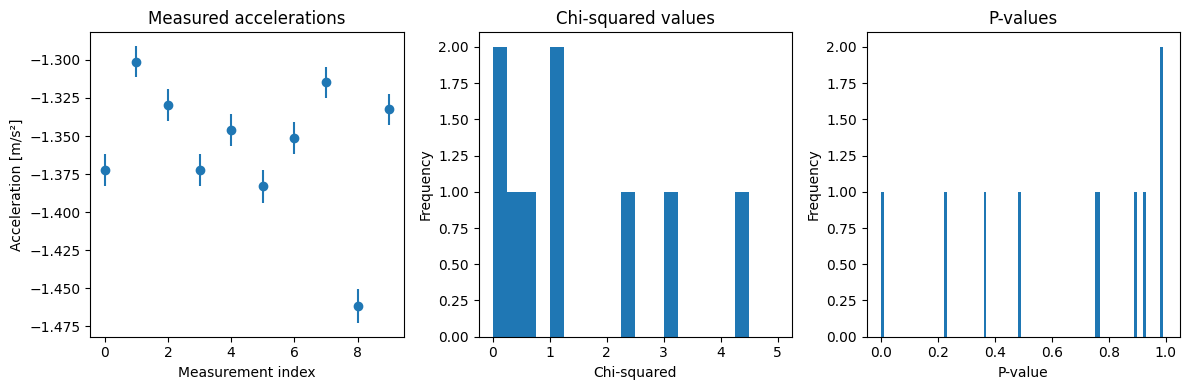

Medium Balls


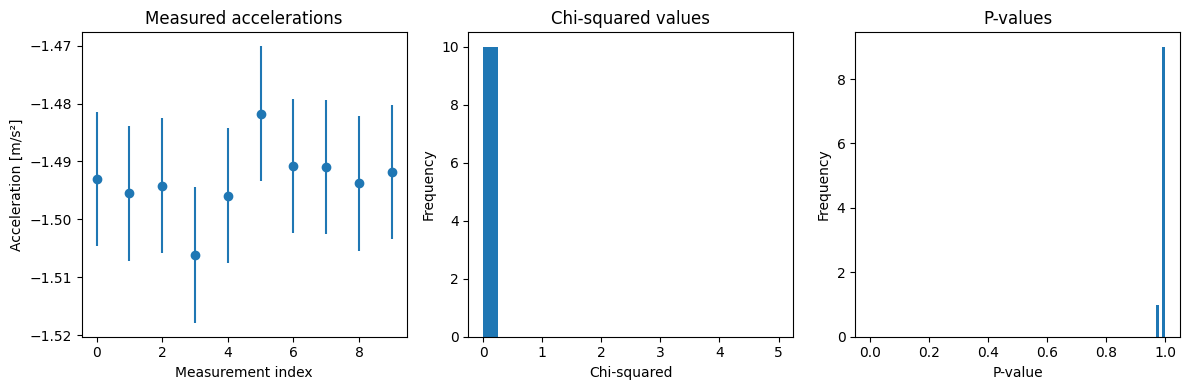

Big Balls


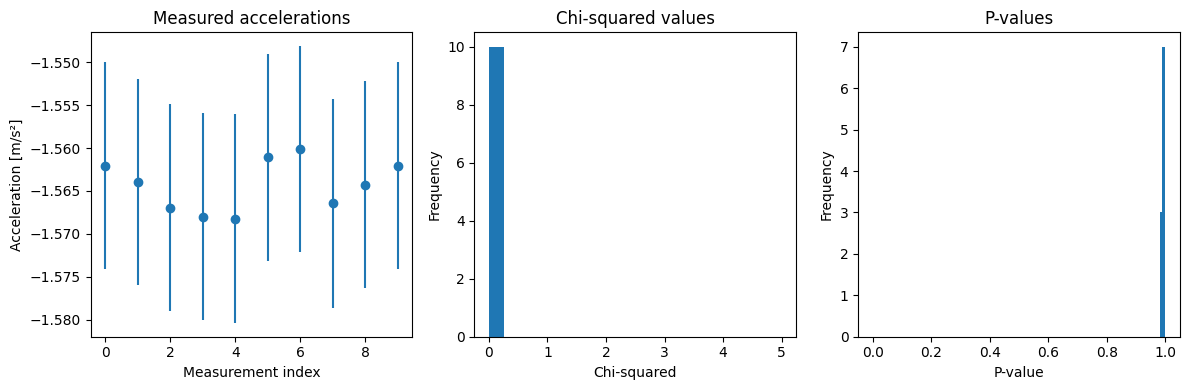

All Balls


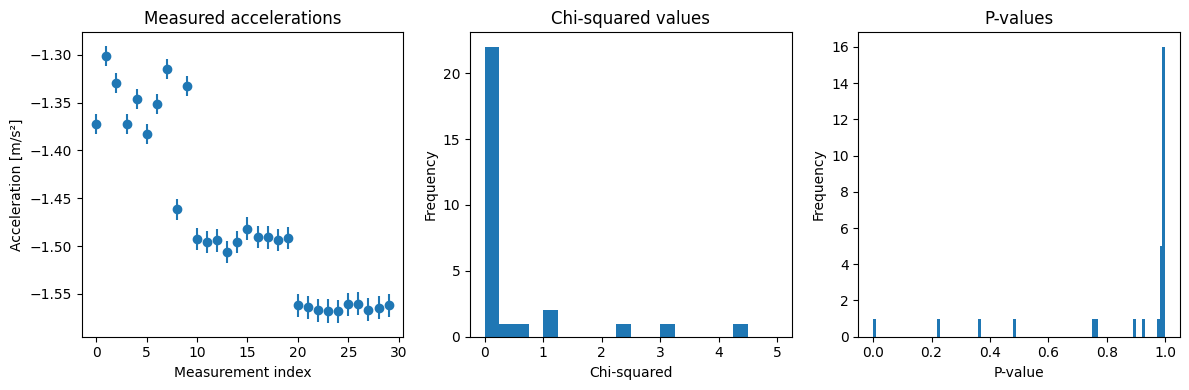

In [161]:
def section_plots(acc, acc_err, chi2_vals, P_vals):
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))

    ax[0].errorbar(range(len(acc)), acc, yerr=acc_err, fmt='o')
    ax[0].set_title('Measured accelerations')
    ax[0].set_xlabel('Measurement index')
    ax[0].set_ylabel('Acceleration [m/s²]')
    ax[1].hist(chi2_vals, bins=20, range=(0,5))
    ax[1].set_title('Chi-squared values')
    ax[1].set_xlabel('Chi-squared')
    ax[1].set_ylabel('Frequency')
    ax[2].hist(P_vals, bins=100, range=(0,1))
    ax[2].set_title('P-values')
    ax[2].set_xlabel('P-value')
    ax[2].set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()

print('Small Balls')
section_plots(acc_s, acc_s_err, chi2_vals_s, P_vals_s)
print('Medium Balls')
section_plots(acc_m, acc_m_err, chi2_vals_m, P_vals_m)
print('Big Balls')
section_plots(acc_b, acc_b_err, chi2_vals_b, P_vals_b)
print('All Balls')
section_plots(acc, acc_err, chi2_vals, P_vals)

# plt.errorbar(range(len(acc)), acc, yerr=acc_err, fmt='o')
# plt.show()

# plt.hist(chi2_vals, bins=20, range=(6.35,7.35))
# plt.show()
# # print(np.sort(chi2_vals))

# print(P_vals)
# plt.hist(P_vals, bins=100, range=(0,0.1))
# plt.show()

In [162]:
print(-np.average(acc[:5], weights=1/acc_err[:5]**2), np.sqrt(1/np.sum(1/acc_err[:5]**2)))
print(-np.average(acc[5:10], weights=1/acc_err[5:10]**2), np.sqrt(1/np.sum(1/acc_err[5:10]**2)))
print(-np.average(acc[10:15], weights=1/acc_err[10:15]**2), np.sqrt(1/np.sum(1/acc_err[10:15]**2)))
print(-np.average(acc[15:20], weights=1/acc_err[15:20]**2), np.sqrt(1/np.sum(1/acc_err[15:20]**2)))
print(-np.average(acc[20:25], weights=1/acc_err[20:25]**2), np.sqrt(1/np.sum(1/acc_err[20:25]**2)))
print(-np.average(acc[25:], weights=1/acc_err[25:]**2), np.sqrt(1/np.sum(1/acc_err[25:]**2)))

1.3436915703375276 0.00465974033649948
1.366029705887927 0.004711577463525824
1.4969245211237874 0.005211084794277411
1.4898079611053425 0.0052038865642483395
1.565819215458601 0.00540110458947797
1.5627802856999353 0.005392231146114868


In [165]:
a_sn, a_sn_err, chi2_sn, P_sn = multiple_accellerations(sbn, locs, loc_error, threshold=1.0)
a_sn = -np.average(a_sn, weights=a_sn_err)
g_sn = a_sn/np.sin(np.radians(theta_avg))*(1 + (2/5)*db_s**2/(db_s**2- d_r**2))

a_sr, a_sr_err, chi2_sr, P_sr = multiple_accellerations(sbr, locs, loc_error, threshold=1.0)
a_sr = -np.average(a_sr, weights=a_sr_err)
g_sr = a_sr/np.sin(np.radians(theta_avg))*(1 + (2/5)*db_s**2/(db_s**2- d_r**2))

a_mn, a_mn_err, chi2_mn, P_mn = multiple_accellerations(mbn, locs, loc_error, threshold=1.0)
a_mn = -np.average(a_mn, weights=a_mn_err)
g_mn = a_mn/np.sin(np.radians(theta_avg))*(1 + (2/5)*db_m**2/(db_m**2- d_r**2))

a_mr, a_mr_err, chi2_mr, P_mr = multiple_accellerations(mbr, locs, loc_error, threshold=1.0)
a_mr = -np.average(a_mr, weights=a_mr_err)
g_mr = a_mr/np.sin(np.radians(theta_avg))*(1 + (2/5)*db_m**2/(db_m**2- d_r**2))

a_bn, a_bn_err, chi2_bn, P_bn = multiple_accellerations(bbn, locs, loc_error, threshold=1.0)
a_bn = -np.average(a_bn, weights=a_bn_err)
g_bn = a_bn/np.sin(np.radians(theta_avg))*(1 + (2/5)*db_b**2/(db_b**2- d_r**2))

a_br, a_br_err, chi2_br, P_br = multiple_accellerations(bbr, locs, loc_error, threshold=1.0)
a_br = -np.average(a_br, weights=a_br_err)
g_br = a_br/np.sin(np.radians(theta_avg))*(1 + (2/5)*db_b**2/(db_b**2- d_r**2))

print(g_sn)
print(g_sr)
print(g_mn)
print(g_mr)
print(g_bn)
print(g_br)
print()
print(np.mean([g_mn, g_mr, g_bn, g_br]))


9.086289847926903
9.25801846494509
9.683921133321148
9.63763900976136
9.587019276509144
9.56846048807343

9.619259976916272
